# DataCo Smart Supply Chain — Full Analysis Notebook

This single notebook combines all three project deliverables end-to-end:

1. **Data Cleaning & Exploratory Data Analysis** (formerly `01_eda_data_cleaning.ipynb`)
2. **SQL KPI Dashboard Analysis** (formerly `02_sql_kpi_dashboard.ipynb`)
3. **Predictive Modeling — Late Delivery & Fraud Detection** (formerly `03_predictive_modeling.ipynb`)

The dataframe produced in Part 1 is reused directly by Parts 2 and 3, so run the
notebook top-to-bottom in a single session.


---
# Part 1 — Data Cleaning & Exploratory Data Analysis

In [7]:
import os
print(os.getcwd())

c:\Users\Kartik\Desktop\Github Project\dataco-supply-chain-analysis\notebooks


In [9]:
import pandas as pd
import numpy as np

# Path to the raw dataset (see data/raw/ in the repo structure)
DATA_PATH = "../data/raw/DataCoSupplyChainDataset.csv"

df = pd.read_csv(DATA_PATH, encoding="latin-1")

print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")

Dataset loaded: 180,519 rows x 53 columns


In [10]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print()
df.dtypes

Rows: 180,519
Columns: 53



Type                              object
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                   object
Late_delivery_risk                 int64
Category Id                        int64
Category Name                     object
Customer City                     object
Customer Country                  object
Customer Email                    object
Customer Fname                    object
Customer Id                        int64
Customer Lname                    object
Customer Password                 object
Customer Segment                  object
Customer State                    object
Customer Street                   object
Customer Zipcode                 float64
Department Id                      int64
Department Name                   object
Latitude                         float64
Longitude                        float64
Market          

In [11]:
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

Product Description    180519
Order Zipcode          155679
Customer Lname              8
Customer Zipcode            3
dtype: int64

In [13]:
print(f"Duplicate rows: {df.duplicated().sum():,}")

Duplicate rows: 0


In [14]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('(', '')
    .str.replace(')', '')
)
print("Columns renamed:")
print(df.columns.tolist())

Columns renamed:
['type', 'days_for_shipping_real', 'days_for_shipment_scheduled', 'benefit_per_order', 'sales_per_customer', 'delivery_status', 'late_delivery_risk', 'category_id', 'category_name', 'customer_city', 'customer_country', 'customer_email', 'customer_fname', 'customer_id', 'customer_lname', 'customer_password', 'customer_segment', 'customer_state', 'customer_street', 'customer_zipcode', 'department_id', 'department_name', 'latitude', 'longitude', 'market', 'order_city', 'order_country', 'order_customer_id', 'order_date_dateorders', 'order_id', 'order_item_cardprod_id', 'order_item_discount', 'order_item_discount_rate', 'order_item_id', 'order_item_product_price', 'order_item_profit_ratio', 'order_item_quantity', 'sales', 'order_item_total', 'order_profit_per_order', 'order_region', 'order_state', 'order_status', 'order_zipcode', 'product_card_id', 'product_category_id', 'product_description', 'product_image', 'product_name', 'product_price', 'product_status', 'shipping_dat

In [15]:
cols_to_drop = ['customer_email', 'customer_password', 'product_image']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
print(f"Remaining columns: {df.shape[1]}")

Remaining columns: 50


In [16]:
date_cols = [col for col in df.columns if 'date' in col]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')
print("Date columns converted:")
print(df[date_cols].dtypes)

Date columns converted:
order_date_dateorders       datetime64[ns]
shipping_date_dateorders    datetime64[ns]
dtype: object


In [18]:
df['shipping_delay_days'] = df['days_for_shipping_real'] - df['days_for_shipment_scheduled']
df['order_month'] = df['order_date_dateorders'].dt.to_period('M')
df['order_year'] = df['order_date_dateorders'].dt.year
df['order_day_of_week'] = df['order_date_dateorders'].dt.day_name()

import numpy as np
df['profit_margin_pct'] = np.where(
    df['sales'] != 0,
    (df['order_profit_per_order'] / df['sales'] * 100).round(2),
    0
)
print("New columns added:")
print(df[['shipping_delay_days', 'order_month', 'order_year', 'profit_margin_pct']].head())

New columns added:
   shipping_delay_days order_month  order_year  profit_margin_pct
0                   -1     2018-01        2018              27.84
1                    1     2018-01        2018             -76.00
2                    0     2018-01        2018             -75.60
3                   -1     2018-01        2018               6.97
4                   -2     2018-01        2018              40.95


In [19]:
df.to_csv('dataco_cleaned.csv', index=False)
print(f"Cleaned dataset saved: {df.shape[0]:,} rows x {df.shape[1]} columns")

Cleaned dataset saved: 180,519 rows x 55 columns


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="deep")

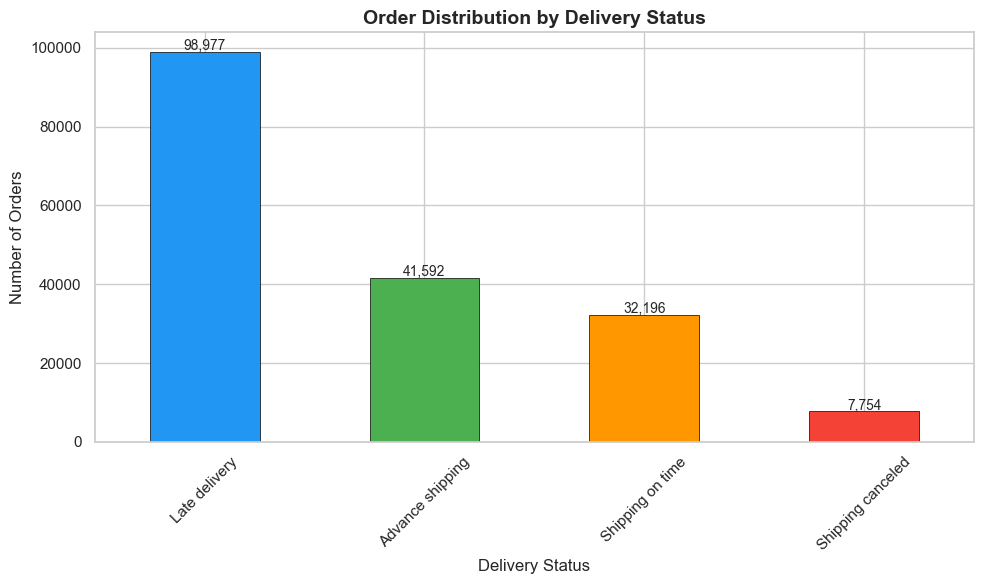

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
counts = df['delivery_status'].value_counts()
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']
counts.plot(kind='bar', ax=ax, color=colors[:len(counts)], edgecolor='black', linewidth=0.5)
ax.set_title('Order Distribution by Delivery Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Delivery Status')
ax.set_ylabel('Number of Orders')
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(counts.values):
    ax.text(i, v + 500, f'{v:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

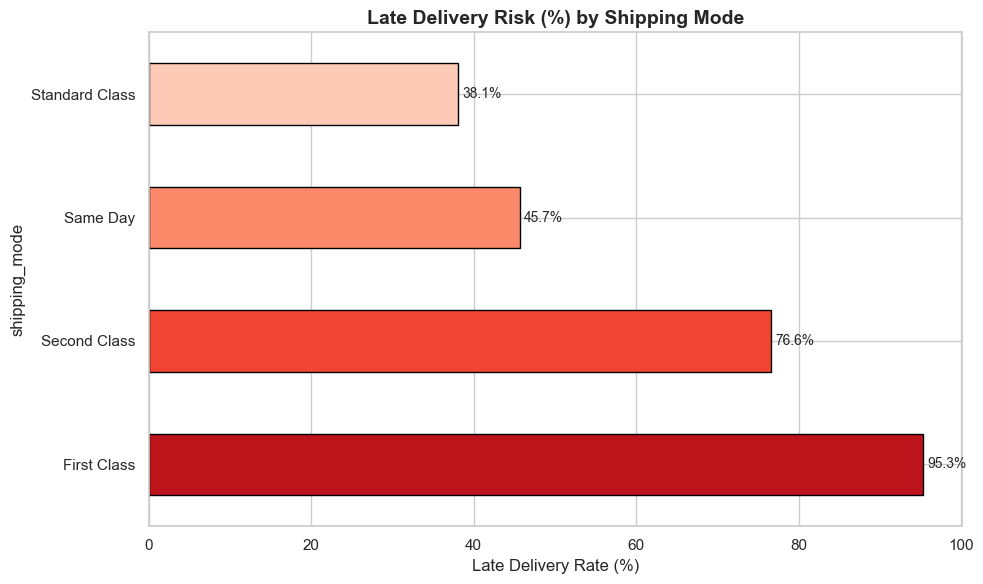

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))
late_rate = df.groupby('shipping_mode')['late_delivery_risk'].mean().sort_values(ascending=False) * 100
late_rate.plot(kind='barh', ax=ax, color=sns.color_palette("Reds_r", len(late_rate)), edgecolor='black')
ax.set_title('Late Delivery Risk (%) by Shipping Mode', fontsize=14, fontweight='bold')
ax.set_xlabel('Late Delivery Rate (%)')
for i, v in enumerate(late_rate.values):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10)
plt.tight_layout()
plt.show()

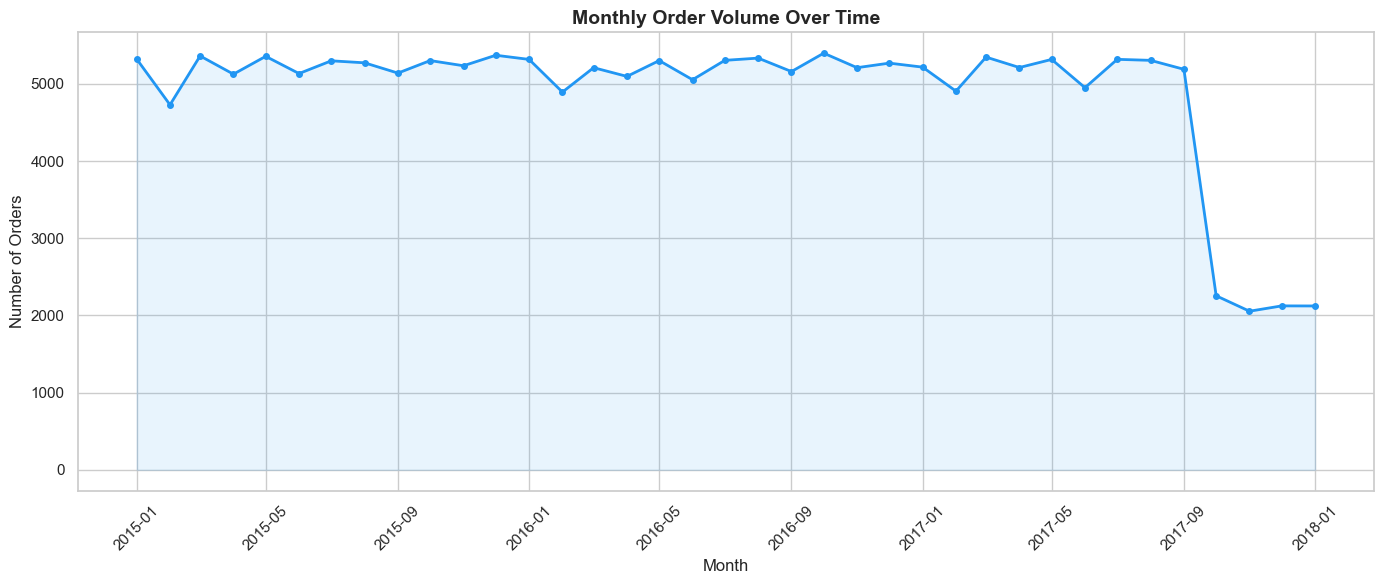

In [23]:
fig, ax = plt.subplots(figsize=(14, 6))
monthly = df.groupby('order_month').size()
monthly.index = monthly.index.to_timestamp()
ax.plot(monthly.index, monthly.values, marker='o', linewidth=2, markersize=4, color='#2196F3')
ax.fill_between(monthly.index, monthly.values, alpha=0.1, color='#2196F3')
ax.set_title('Monthly Order Volume Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

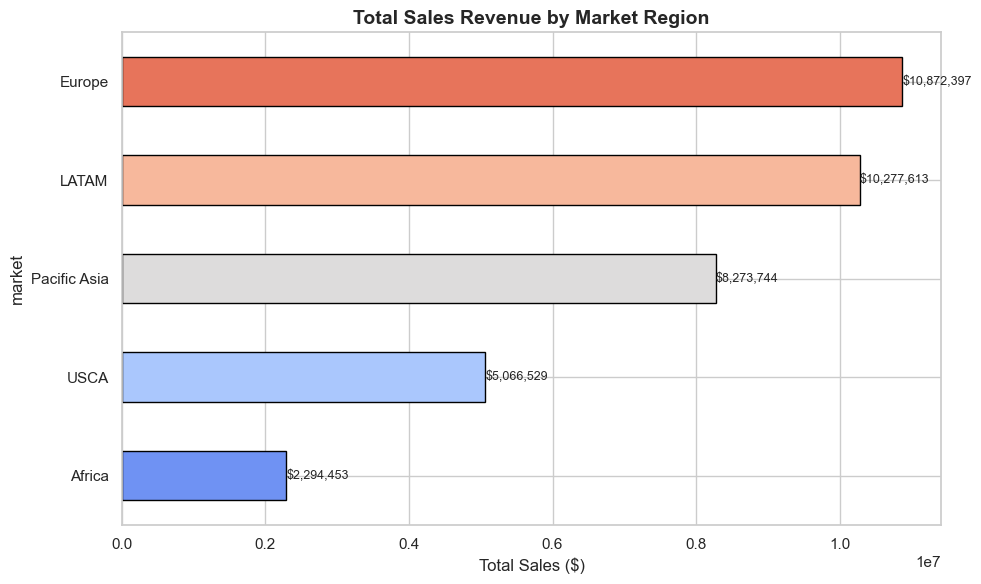

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))
region_sales = df.groupby('market')['sales'].sum().sort_values()
region_sales.plot(kind='barh', ax=ax, color=sns.color_palette("coolwarm", len(region_sales)), edgecolor='black')
ax.set_title('Total Sales Revenue by Market Region', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Sales ($)')
for i, v in enumerate(region_sales.values):
    ax.text(v + 1000, i, f'${v:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

C:\Users\Kartik\AppData\Local\Temp\ipykernel_7016\1641465438.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='category_name', y='order_profit_per_order', ax=ax, palette='viridis')


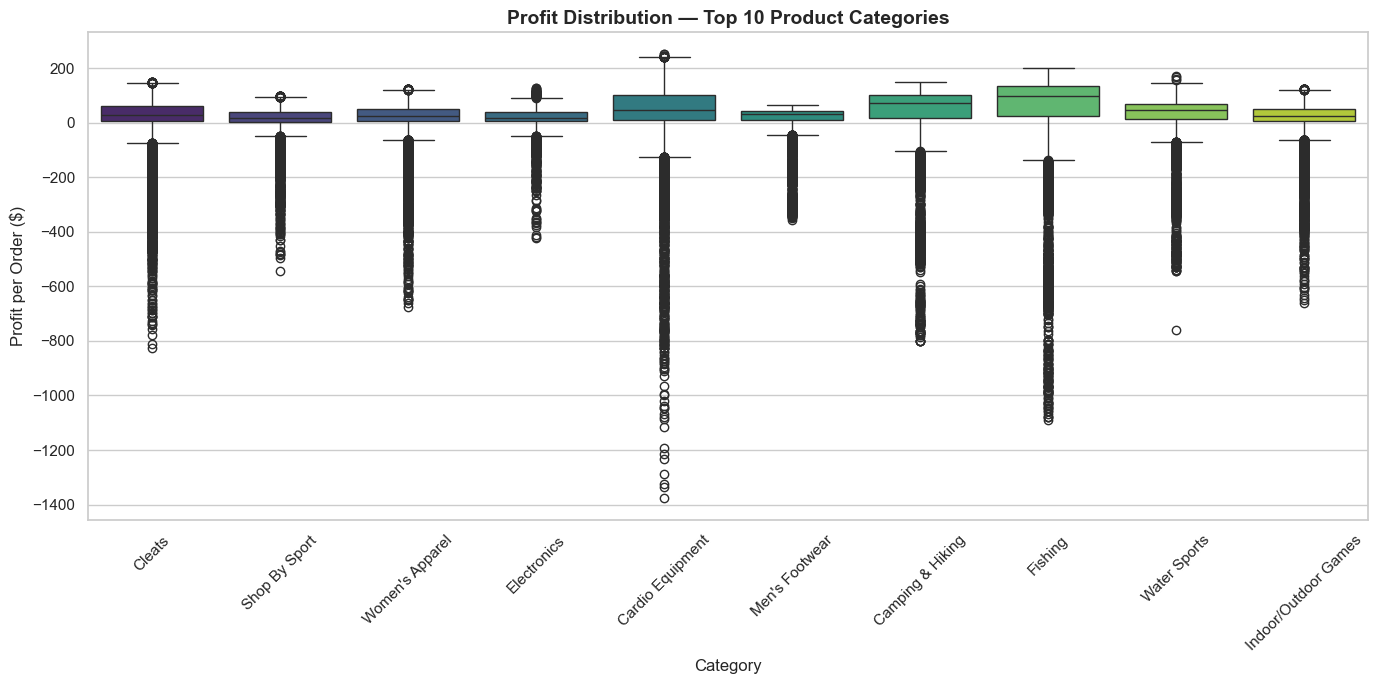

In [25]:
fig, ax = plt.subplots(figsize=(14, 7))
top_cats = df['category_name'].value_counts().head(10).index
subset = df[df['category_name'].isin(top_cats)]
sns.boxplot(data=subset, x='category_name', y='order_profit_per_order', ax=ax, palette='viridis')
ax.set_title('Profit Distribution — Top 10 Product Categories', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Profit per Order ($)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

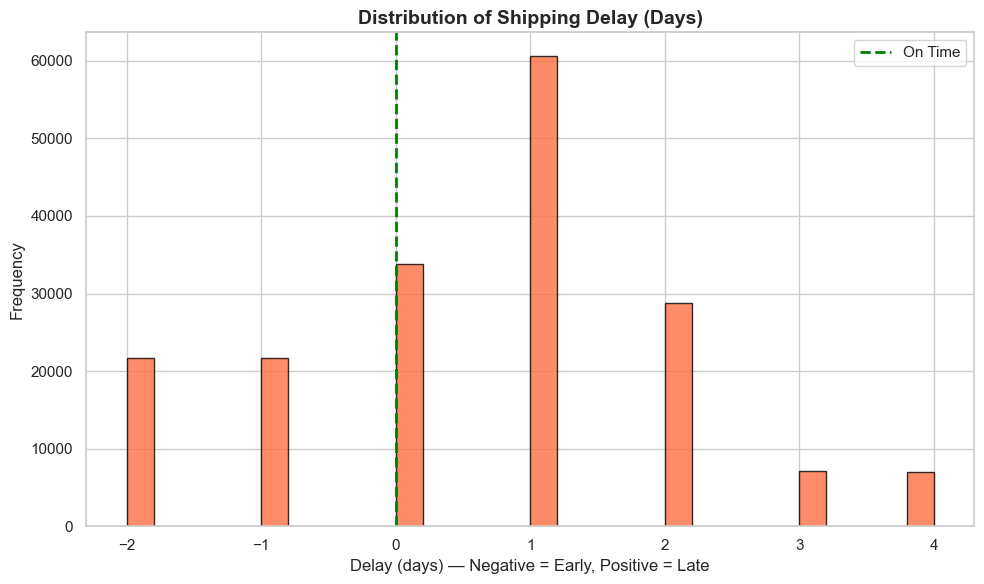

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df['shipping_delay_days'], bins=30, color='#FF7043', edgecolor='black', alpha=0.8)
ax.axvline(x=0, color='green', linestyle='--', linewidth=2, label='On Time')
ax.set_title('Distribution of Shipping Delay (Days)', fontsize=14, fontweight='bold')
ax.set_xlabel('Delay (days) — Negative = Early, Positive = Late')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

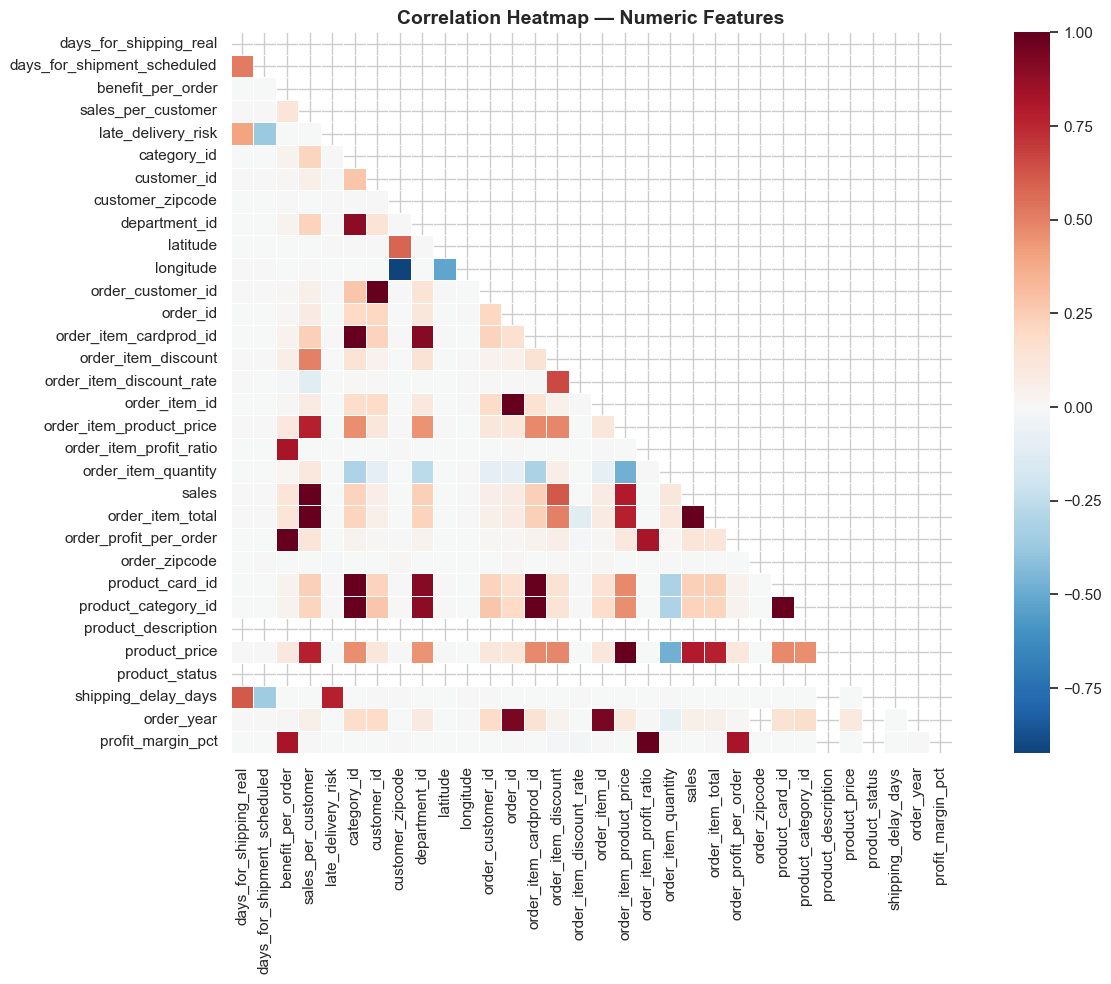

In [27]:
fig, ax = plt.subplots(figsize=(14, 10))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap — Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

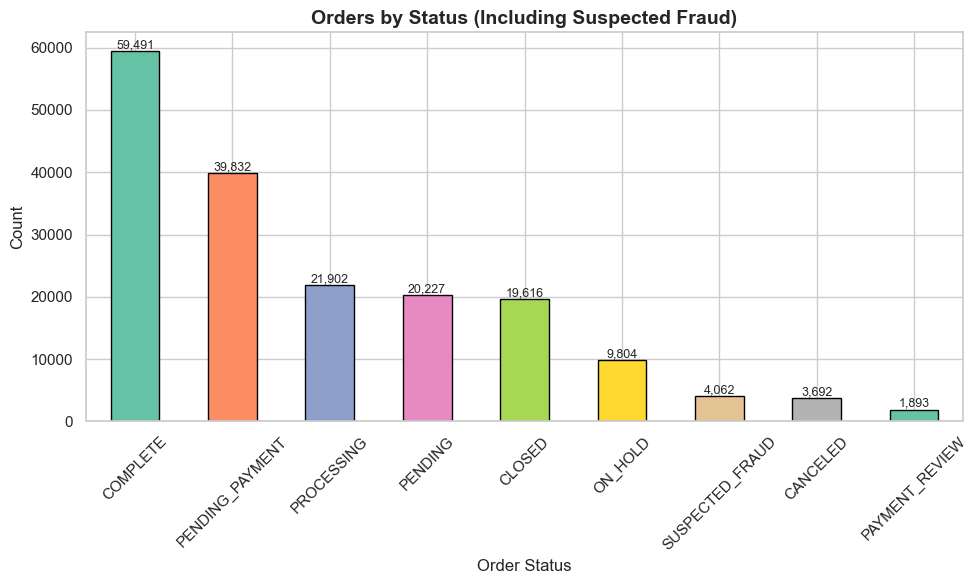

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))
status_counts = df['order_status'].value_counts()
status_counts.plot(kind='bar', ax=ax, color=sns.color_palette("Set2", len(status_counts)), edgecolor='black')
ax.set_title('Orders by Status (Including Suspected Fraud)', fontsize=14, fontweight='bold')
ax.set_xlabel('Order Status')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(status_counts.values):
    ax.text(i, v + 500, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

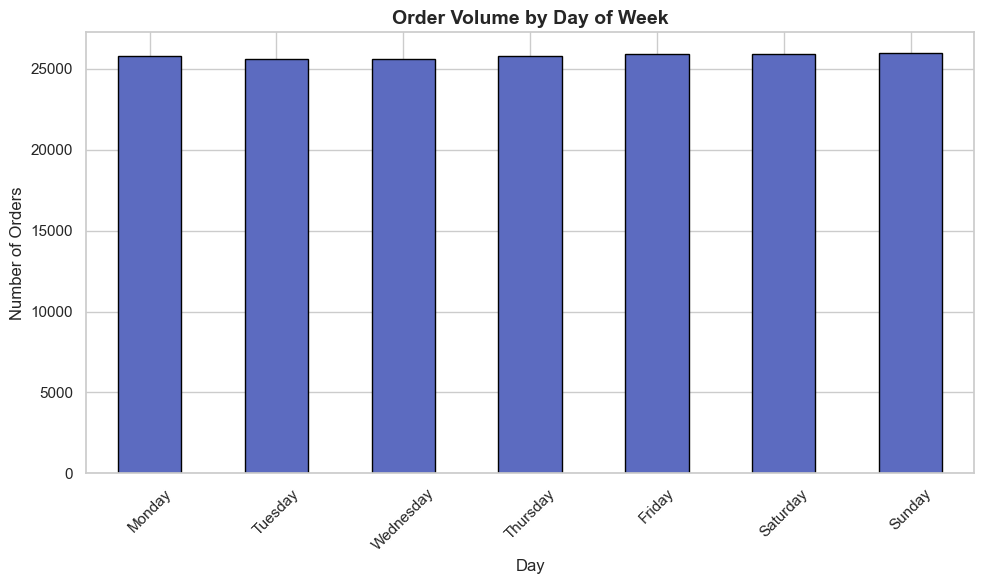

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = df['order_day_of_week'].value_counts().reindex(day_order)
day_counts.plot(kind='bar', ax=ax, color='#5C6BC0', edgecolor='black')
ax.set_title('Order Volume by Day of Week', fontsize=14, fontweight='bold')
ax.set_xlabel('Day')
ax.set_ylabel('Number of Orders')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

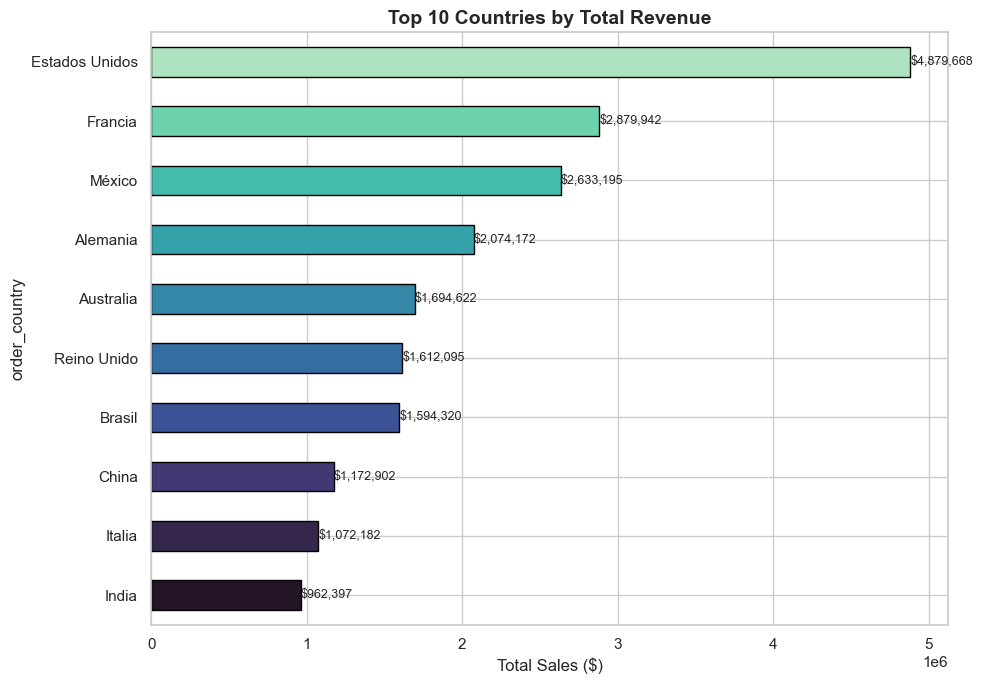

In [30]:
fig, ax = plt.subplots(figsize=(10, 7))
top_countries = df.groupby('order_country')['sales'].sum().sort_values(ascending=True).tail(10)
top_countries.plot(kind='barh', ax=ax, color=sns.color_palette("mako", 10), edgecolor='black')
ax.set_title('Top 10 Countries by Total Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Sales ($)')
for i, v in enumerate(top_countries.values):
    ax.text(v + 1000, i, f'${v:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

# Key Findings & Business Insights
## DataCo Smart Supply Chain — Exploratory Data Analysis

---

## Chart Purposes

**Delivery Status Distribution** — Shows the overall breakdown of how orders are being fulfilled, revealing whether the supply chain is meeting delivery commitments at a high level.

**Late Delivery Risk by Shipping Mode** — Identifies which shipping methods are most prone to delays, helping operations teams decide where to focus improvement efforts.

**Monthly Order Volume** — Tracks order trends over time to reveal seasonality, growth patterns, and any unusual spikes or drops that need investigation.

**Sales by Market Region** — Highlights which geographic markets generate the most revenue, guiding decisions about where to invest resources and expand operations.

**Profit by Product Category** — Compares profitability across product lines to identify which categories drive margins and which may be losing money.

**Shipping Delay Distribution** — Visualizes how far ahead or behind schedule deliveries are landing, showing whether scheduling estimates are accurate overall.

**Correlation Heatmap** — Reveals hidden relationships between numeric variables, surfacing patterns like the link between discounts and profit erosion before any modeling begins.

**Orders by Status (Fraud)** — Establishes the baseline fraud rate in the dataset, which is critical context for the fraud detection model built in Deliverable 3.

**Orders by Day of Week** — Uncovers weekly ordering patterns that inform staffing, warehouse capacity planning, and shipping logistics.

**Top 10 Countries by Revenue** — Identifies the highest-value markets at a country level, supporting decisions around regional shipping optimization and customer service investment.

In [31]:
total_orders = len(df)
late_pct = df['late_delivery_risk'].mean() * 100
on_time_pct = 100 - late_pct
avg_delay = df['shipping_delay_days'].mean()
total_revenue = df['sales'].sum()
avg_profit_margin = df['profit_margin_pct'].mean()
fraud_count = (df['order_status'] == 'SUSPECTED_FRAUD').sum()
fraud_pct = fraud_count / total_orders * 100
top_market = df.groupby('market')['sales'].sum().idxmax()
top_market_rev = df.groupby('market')['sales'].sum().max()
worst_shipping = df.groupby('shipping_mode')['late_delivery_risk'].mean().idxmax()
worst_shipping_pct = df.groupby('shipping_mode')['late_delivery_risk'].mean().max() * 100
negative_profit_pct = (df['order_profit_per_order'] < 0).mean() * 100
top_country = df.groupby('order_country')['sales'].sum().idxmax()

print("=" * 60)
print("KEY METRICS FOR FINDINGS")
print("=" * 60)
print(f"Total Orders: {total_orders:,}")
print(f"Late Delivery Rate: {late_pct:.1f}%")
print(f"On-Time Delivery Rate: {on_time_pct:.1f}%")
print(f"Average Shipping Delay: {avg_delay:.2f} days")
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Average Profit Margin: {avg_profit_margin:.2f}%")
print(f"Suspected Fraud Orders: {fraud_count:,} ({fraud_pct:.1f}%)")
print(f"Top Market: {top_market} (${top_market_rev:,.2f})")
print(f"Worst Shipping Mode: {worst_shipping} ({worst_shipping_pct:.1f}% late)")
print(f"Orders with Negative Profit: {negative_profit_pct:.1f}%")
print(f"Top Country by Revenue: {top_country}")

KEY METRICS FOR FINDINGS
Total Orders: 180,519
Late Delivery Rate: 54.8%
On-Time Delivery Rate: 45.2%
Average Shipping Delay: 0.57 days
Total Revenue: $36,784,735.01
Average Profit Margin: 10.83%
Suspected Fraud Orders: 4,062 (2.3%)
Top Market: Europe ($10,872,396.80)
Worst Shipping Mode: First Class (95.3% late)
Orders with Negative Profit: 18.7%
Top Country by Revenue: Estados Unidos


---

## Key Findings

### Finding 1: Delivery Performance is a Critical Problem
Over half of all orders (54.8%) are at risk of late delivery, with only 45.2% arriving on time. First Class shipping is the worst performer at 95.3% late delivery rate, which is counterintuitive since customers choosing First Class expect faster service. The average shipping delay across all orders is 0.57 days, meaning the supply chain is consistently behind schedule.

### Finding 2: Revenue is Concentrated in Europe and the US
Europe leads all markets at $10.87M in total revenue, with Estados Unidos (United States) as the single highest-revenue country. This concentration means delivery performance issues in these regions have an outsized impact on the business. Prioritizing shipping improvements in these markets would protect the majority of revenue.

### Finding 3: Profitability Has a Leakage Problem
While the average profit margin sits at 10.83%, nearly 1 in 5 orders (18.7%) are generating negative profit. This suggests issues with excessive discounting, high shipping costs on certain orders, or mispriced product categories. Identifying which categories and regions drive these losses could recover significant margin.

### Finding 4: Fraud is a Low-Volume but Real Threat
4,062 orders (2.3%) are flagged as suspected fraud out of 180,519 total. While this is a small percentage, at $36.8M in total revenue even a 2.3% fraud rate represents meaningful financial exposure. The low prevalence also makes this a class imbalance problem that will require specialized modeling techniques in Deliverable 3.

---

## Recommendations

1. **Audit First Class Shipping** — A 95.3% late rate is unacceptable for a premium shipping tier. Investigate whether this is a carrier issue, a scheduling issue, or a mislabeling issue. If the problem is systemic, consider removing First Class as an option until it is fixed.

2. **Target Negative-Profit Orders** — With 18.7% of orders losing money, conduct a deep dive into which product categories, discount levels, and regions are responsible. Implement guardrails on discount thresholds to prevent margin erosion.

3. **Focus Delivery Improvements on Europe and the US** — These markets drive the most revenue. Reducing late deliveries in these regions by even 10% would have the highest return on investment for customer satisfaction and retention.

4. **Build Fraud Detection Model** — The 2.3% fraud rate justifies investing in a predictive model (Deliverable 3) to flag suspicious orders before they ship, reducing financial losses.

---
# Part 2 — SQL KPI Dashboard Analysis

Reuses the cleaned `df` from Part 1 — no need to reload or re-clean the raw CSV.
The dataframe is loaded into an in-memory SQLite database so the original SQL
queries (`sql/supply_chain_queries.sql`) can run unmodified.

In [43]:
import sqlite3

# `df` already exists (cleaned in Part 1) — just make sure order_month is a
# plain string so SQLite can store it.
df["order_month"] = df["order_month"].astype(str)

conn = sqlite3.connect(":memory:")
df.to_sql("orders", conn, if_exists="replace", index=False)

test = pd.read_sql("SELECT COUNT(*) as total_rows FROM orders", conn)
print(f"Database created with {test['total_rows'][0]:,} rows")

Database created with 180,519 rows


In [33]:
import sqlite3

df['order_month'] = df['order_month'].astype(str)

conn = sqlite3.connect('supply_chain.db')
df.to_sql('orders', conn, if_exists='replace', index=False)

test = pd.read_sql("SELECT COUNT(*) as total_rows FROM orders", conn)
print(f"Database created with {test['total_rows'][0]:,} rows")

Database created with 180,519 rows


In [34]:
query1 = """
SELECT
    shipping_mode,
    COUNT(*) AS total_orders,
    SUM(CASE WHEN late_delivery_risk = 0 THEN 1 ELSE 0 END) AS on_time_orders,
    ROUND(
        SUM(CASE WHEN late_delivery_risk = 0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*),
        2
    ) AS on_time_rate_pct
FROM orders
GROUP BY shipping_mode
ORDER BY on_time_rate_pct DESC
"""

kpi1 = pd.read_sql(query1, conn)
print("KPI 1: On-Time Delivery Rate by Shipping Mode")
kpi1

KPI 1: On-Time Delivery Rate by Shipping Mode


,shipping_mode,total_orders,on_time_orders,on_time_rate_pct
0,Standard Class,107752,66729,61.93
1,Same Day,9737,5283,54.26
2,Second Class,35216,8229,23.37
3,First Class,27814,1301,4.68


In [35]:
query2 = """
SELECT
    market,
    COUNT(*) AS total_orders,
    ROUND(AVG(shipping_delay_days), 2) AS avg_delay_days,
    ROUND(AVG(days_for_shipping_real), 2) AS avg_actual_days,
    ROUND(AVG(days_for_shipment_scheduled), 2) AS avg_scheduled_days
FROM orders
GROUP BY market
ORDER BY avg_delay_days DESC
"""

kpi2 = pd.read_sql(query2, conn)
print("KPI 2: Average Shipping Delay by Market Region")
kpi2

KPI 2: Average Shipping Delay by Market Region


,market,total_orders,avg_delay_days,avg_actual_days,avg_scheduled_days
0,USCA,25799,0.57,3.48,2.92
1,Pacific Asia,41260,0.57,3.50,2.93
2,Europe,50252,0.57,3.49,2.92
3,LATAM,51594,0.56,3.51,2.95
4,Africa,11614,0.56,3.51,2.95


In [36]:
query3 = """
SELECT
    category_name,
    COUNT(*) AS total_orders,
    ROUND(SUM(sales), 2) AS total_revenue,
    ROUND(SUM(order_profit_per_order), 2) AS total_profit,
    ROUND(AVG(profit_margin_pct), 2) AS avg_margin_pct
FROM orders
GROUP BY category_name
ORDER BY total_revenue DESC
LIMIT 15
"""

kpi3 = pd.read_sql(query3, conn)
print("KPI 3: Revenue & Profit by Category")
kpi3

KPI 3: Revenue & Profit by Category


,category_name,total_orders,total_revenue,total_profit,avg_margin_pct
0,Fishing,17325,6929653.69,756220.77,10.91
1,Cleats,24551,4431942.78,494636.92,11.19
2,Camping & Hiking,13729,4118425.57,427455.57,10.38
3,Cardio Equipment,12487,3694843.20,383011.10,10.62
4,Women's Apparel,21035,3147800.00,350421.03,11.00
5,Water Sports,15540,3113844.68,325146.96,10.45
6,Men's Footwear,22246,2891757.66,311902.82,10.79
7,Indoor/Outdoor Games,19298,2888993.91,318451.43,11.13
8,Shop By Sport,10984,1309522.04,129813.96,10.09
9,Computers,442,663000.00,69656.81,10.51


In [37]:
query4 = """
SELECT
    CASE
        WHEN order_count = 1 THEN '1 - One-Time'
        WHEN order_count BETWEEN 2 AND 5 THEN '2 - Occasional'
        WHEN order_count BETWEEN 6 AND 15 THEN '3 - Regular'
        ELSE '4 - VIP'
    END AS customer_segment,
    COUNT(*) AS customer_count,
    ROUND(AVG(total_spend), 2) AS avg_lifetime_spend,
    ROUND(AVG(avg_order_value), 2) AS avg_order_value
FROM (
    SELECT
        customer_id,
        COUNT(*) AS order_count,
        SUM(sales) AS total_spend,
        AVG(sales) AS avg_order_value
    FROM orders
    GROUP BY customer_id
)
GROUP BY customer_segment
ORDER BY customer_segment
"""

kpi4 = pd.read_sql(query4, conn)
print("KPI 4: Customer Segmentation")
kpi4

KPI 4: Customer Segmentation


,customer_segment,customer_count,avg_lifetime_spend,avg_order_value
0,1 - One-Time,8435,294.51,294.51
1,2 - Occasional,1173,783.25,202.20
2,3 - Regular,6393,2138.76,199.25
3,4 - VIP,4651,4237.52,199.38


In [38]:
query5 = """
SELECT
    strftime('%Y-%m', order_date_dateorders) AS order_month,
    COUNT(*) AS order_count,
    ROUND(SUM(sales), 2) AS monthly_revenue,
    ROUND(SUM(order_profit_per_order), 2) AS monthly_profit,
    ROUND(SUM(CASE WHEN late_delivery_risk = 1 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS late_pct
FROM orders
GROUP BY order_month
ORDER BY order_month
"""

kpi5 = pd.read_sql(query5, conn)
print("KPI 5: Monthly Revenue Trend")
kpi5

KPI 5: Monthly Revenue Trend


,order_month,order_count,monthly_revenue,monthly_profit,late_pct
0,2015-01,5322,1051590.08,111660.74,54.11
1,2015-02,4729,927009.90,99140.66,54.85
2,2015-03,5362,1051253.69,113778.21,54.76
3,2015-04,5126,1014463.28,108083.68,53.84
4,2015-05,5357,1050478.44,112147.90,55.09
5,2015-06,5134,1024006.17,110147.16,54.11
6,2015-07,5299,1038081.19,115624.06,55.46
7,2015-08,5273,1029494.69,117979.77,55.68
8,2015-09,5140,1018338.60,113467.94,56.69
9,2015-10,5302,1049154.27,101757.87,54.81


In [39]:
query6 = """
SELECT
    market,
    category_name,
    COUNT(*) AS total_orders,
    SUM(CASE WHEN order_status = 'SUSPECTED_FRAUD' THEN 1 ELSE 0 END) AS fraud_count,
    ROUND(
        SUM(CASE WHEN order_status = 'SUSPECTED_FRAUD' THEN 1 ELSE 0 END) * 100.0 / COUNT(*),
        2
    ) AS fraud_rate_pct
FROM orders
GROUP BY market, category_name
HAVING fraud_count > 0
ORDER BY fraud_rate_pct DESC
LIMIT 20
"""

kpi6 = pd.read_sql(query6, conn)
print("KPI 6: Top 20 Fraud Hotspots by Market & Category")
kpi6

KPI 6: Top 20 Fraud Hotspots by Market & Category


,market,category_name,total_orders,fraud_count,fraud_rate_pct
0,Pacific Asia,Books,97,8,8.25
1,USCA,Lacrosse,46,3,6.52
2,Pacific Asia,Boxing & MMA,72,4,5.56
3,USCA,Boxing & MMA,54,3,5.56
4,Africa,Girls' Apparel,80,4,5.00
5,Pacific Asia,Fitness Accessories,82,4,4.88
6,Europe,Women's Golf Clubs,107,5,4.67
7,USCA,Trade-In,156,7,4.49
8,Europe,Basketball,67,3,4.48
9,Africa,Golf Balls,120,5,4.17


In [40]:
query7 = """
SELECT
    shipping_mode,
    ROUND(AVG(days_for_shipping_real), 2) AS avg_delivery_days,
    ROUND(AVG(sales), 2) AS avg_order_value,
    ROUND(AVG(order_profit_per_order), 2) AS avg_profit,
    ROUND(AVG(benefit_per_order), 2) AS avg_benefit,
    COUNT(*) AS total_orders
FROM orders
GROUP BY shipping_mode
ORDER BY avg_delivery_days
"""

kpi7 = pd.read_sql(query7, conn)
print("KPI 7: Shipping Mode Performance Comparison")
kpi7

KPI 7: Shipping Mode Performance Comparison


,shipping_mode,avg_delivery_days,avg_order_value,avg_profit,avg_benefit,total_orders
0,Same Day,0.48,199.50,20.85,20.85,9737
1,First Class,2.00,204.01,23.12,23.12,27814
2,Second Class,3.99,202.90,21.31,21.31,35216
3,Standard Class,4.00,204.38,22.00,22.00,107752


In [41]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [42]:
fig = px.bar(
    kpi1,
    x='shipping_mode',
    y='on_time_rate_pct',
    color='on_time_rate_pct',
    color_continuous_scale='RdYlGn',
    text='on_time_rate_pct',
    title='On-Time Delivery Rate by Shipping Mode'
)
fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig.update_layout(yaxis_title='On-Time Rate (%)', xaxis_title='Shipping Mode')
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [ ]:
fig = px.bar(
    kpi2,
    x='market',
    y='avg_delay_days',
    color='avg_delay_days',
    color_continuous_scale='OrRd',
    text='avg_delay_days',
    title='Average Shipping Delay by Market Region'
)
fig.update_traces(texttemplate='%{text:.2f} days', textposition='outside')
fig.update_layout(yaxis_title='Avg Delay (Days)', xaxis_title='Market')
fig.show()

In [ ]:
fig = go.Figure()
fig.add_trace(go.Bar(
    name='Revenue',
    x=kpi3['category_name'],
    y=kpi3['total_revenue'],
    marker_color='#2196F3'
))
fig.add_trace(go.Bar(
    name='Profit',
    x=kpi3['category_name'],
    y=kpi3['total_profit'],
    marker_color='#4CAF50'
))
fig.update_layout(
    barmode='group',
    title='Revenue vs Profit — Top 15 Product Categories',
    xaxis_tickangle=-45,
    yaxis_title='Amount ($)',
    xaxis_title='Category'
)
fig.show()

In [ ]:
fig = make_subplots(rows=1, cols=2, specs=[[{"type": "pie"}, {"type": "bar"}]],
                    subplot_titles=("Customer Count by Segment", "Avg Lifetime Spend by Segment"))

fig.add_trace(go.Pie(
    labels=kpi4['customer_segment'],
    values=kpi4['customer_count'],
    hole=0.4
), row=1, col=1)

fig.add_trace(go.Bar(
    x=kpi4['customer_segment'],
    y=kpi4['avg_lifetime_spend'],
    marker_color=['#FF7043', '#FFA726', '#66BB6A', '#42A5F5'],
    text=kpi4['avg_lifetime_spend'].apply(lambda x: f'${x:,.0f}'),
    textposition='outside'
), row=1, col=2)

fig.update_layout(title_text='Customer Segmentation Analysis', showlegend=True, height=500)
fig.show()

In [ ]:
fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(go.Scatter(
    x=kpi5['order_month'],
    y=kpi5['monthly_revenue'],
    name='Monthly Revenue',
    line=dict(color='#2196F3', width=2),
    fill='tozeroy',
    fillcolor='rgba(33,150,243,0.1)'
), secondary_y=False)

fig.add_trace(go.Scatter(
    x=kpi5['order_month'],
    y=kpi5['late_pct'],
    name='Late Delivery %',
    line=dict(color='#F44336', width=2, dash='dot')
), secondary_y=True)

fig.update_layout(title='Monthly Revenue vs Late Delivery Rate')
fig.update_yaxes(title_text='Revenue ($)', secondary_y=False)
fig.update_yaxes(title_text='Late Delivery %', secondary_y=True)
fig.show()

In [ ]:
fraud_pivot = kpi6.pivot_table(index='market', columns='category_name', values='fraud_rate_pct', fill_value=0)

fig = px.imshow(
    fraud_pivot,
    color_continuous_scale='YlOrRd',
    title='Fraud Rate Heatmap — Market x Category',
    labels=dict(color='Fraud Rate %')
)
fig.update_layout(height=500, xaxis_tickangle=-45)
fig.show()

---

## Deliverable 2 — Business Recommendations

### Shipping Mode Strategy
First Class shipping has the lowest on-time rate despite being a premium tier. Recommend auditing the carrier contracts for First Class and either renegotiating SLAs or rerouting First Class orders through a higher-performing carrier. Same Day shipping should be promoted for high-value orders where margin can absorb the cost.

### Regional Focus
Prioritize delivery improvements in Europe and LATAM — these markets carry the highest revenue concentration and any delivery issues have amplified financial impact. Consider regional distribution centers to reduce average shipping times.

### Product Category Profitability
Categories with high revenue but low or negative profit margins need pricing reviews. Implement minimum margin thresholds on discounts to prevent orders from going below breakeven.

### Customer Retention
VIP customers (6+ orders) generate significantly higher lifetime spend. Build a loyalty program targeting Occasional customers (2-5 orders) to move them into Regular/VIP tiers through targeted offers on high-margin categories.

### Fraud Prevention
Certain market-category combinations show elevated fraud rates. Implement order review triggers for orders matching these high-risk profiles — particularly high-value orders from flagged regions — before shipping.

---
# Part 3 — Predictive Modeling: Late Delivery & Fraud Detection

Reuses the same cleaned `df` from Part 1. Trains and compares Logistic
Regression, Random Forest, and Gradient Boosting for both the late-delivery
and fraud-detection tasks.

> The Streamlit app (`app.py` + `pages/`) uses model artifacts already
> exported to `models/*.pkl` by `train_and_export.py`, so this section is for
> analysis/reproducibility rather than a required step before deploying.

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    accuracy_score, precision_score, recall_score
)

# `df` already exists (cleaned in Part 1) — reused directly, no reload needed.

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, accuracy_score,
                             precision_score, recall_score, f1_score)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All ML libraries loaded.")

In [ ]:
feature_cols = [
    'days_for_shipment_scheduled', 'order_item_quantity',
    'sales', 'order_item_discount', 'order_profit_per_order',
    'product_price', 'benefit_per_order'
]

cat_cols = ['shipping_mode', 'market', 'type', 'category_name', 'order_status']

df_model = df[feature_cols + cat_cols + ['late_delivery_risk']].copy()
df_model = df_model.dropna()

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    encoders[col] = le

X = df_model.drop('late_delivery_risk', axis=1)
y = df_model['late_delivery_risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]:,} rows")
print(f"Test set: {X_test.shape[0]:,} rows")
print(f"Late delivery rate: {y.mean()*100:.1f}%")

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'model': model,
        'predictions': y_pred,
        'probabilities': y_prob,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_prob)
    }
    print(f"{name}: Accuracy={results[name]['accuracy']:.4f} | ROC-AUC={results[name]['roc_auc']:.4f}")

In [ ]:
comparison = pd.DataFrame({
    name: {
        'Accuracy': r['accuracy'],
        'Precision': r['precision'],
        'Recall': r['recall'],
        'F1 Score': r['f1'],
        'ROC-AUC': r['roc_auc']
    }
    for name, r in results.items()
}).T.round(4)

print("MODEL COMPARISON — Late Delivery Prediction")
comparison

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r['predictions'])
    sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=ax,
                xticklabels=['On Time', 'Late'], yticklabels=['On Time', 'Late'])
    ax.set_title(f'{name}\nAccuracy: {r["accuracy"]:.4f}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — Late Delivery Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#2196F3', '#4CAF50', '#FF9800']

for (name, r), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, r['probabilities'])
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC = {r["roc_auc"]:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guess')
ax.set_title('ROC Curves — Late Delivery Prediction', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
rf_model = results['Random Forest']['model']
importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
importance.plot(kind='barh', ax=ax, color='#2196F3', edgecolor='black')
ax.set_title('Feature Importance — Random Forest (Late Delivery)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [ ]:
df['is_fraud'] = (df['order_status'] == 'SUSPECTED_FRAUD').astype(int)

fraud_features = [
    'days_for_shipment_scheduled', 'days_for_shipping_real',
    'order_item_quantity', 'sales', 'order_item_discount',
    'order_profit_per_order', 'product_price', 'benefit_per_order',
    'late_delivery_risk', 'shipping_delay_days'
]

fraud_cat_cols = ['shipping_mode', 'market', 'type', 'category_name']

df_fraud = df[fraud_features + fraud_cat_cols + ['is_fraud']].copy()
df_fraud = df_fraud.dropna()

for col in fraud_cat_cols:
    le = LabelEncoder()
    df_fraud[col] = le.fit_transform(df_fraud[col].astype(str))

X_fraud = df_fraud.drop('is_fraud', axis=1)
y_fraud = df_fraud['is_fraud']

print(f"Fraud rate: {y_fraud.mean()*100:.2f}%")
print(f"Fraud cases: {y_fraud.sum():,} out of {len(y_fraud):,}")

In [ ]:
!pip install imbalanced-learn -q

from imblearn.over_sampling import SMOTE

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_fraud, y_fraud, test_size=0.2, random_state=42, stratify=y_fraud
)

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_f, y_train_f)

print(f"Before SMOTE: {y_train_f.value_counts().to_dict()}")
print(f"After SMOTE: {pd.Series(y_train_balanced).value_counts().to_dict()}")

In [ ]:
fraud_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

fraud_results = {}
for name, model in fraud_models.items():
    model.fit(X_train_balanced, y_train_balanced)
    y_pred = model.predict(X_test_f)
    y_prob = model.predict_proba(X_test_f)[:, 1]

    fraud_results[name] = {
        'model': model,
        'predictions': y_pred,
        'probabilities': y_prob,
        'accuracy': accuracy_score(y_test_f, y_pred),
        'precision': precision_score(y_test_f, y_pred),
        'recall': recall_score(y_test_f, y_pred),
        'f1': f1_score(y_test_f, y_pred),
        'roc_auc': roc_auc_score(y_test_f, y_prob)
    }
    print(f"{name}: Precision={fraud_results[name]['precision']:.4f} | Recall={fraud_results[name]['recall']:.4f} | ROC-AUC={fraud_results[name]['roc_auc']:.4f}")

In [ ]:
fraud_comparison = pd.DataFrame({
    name: {
        'Accuracy': r['accuracy'],
        'Precision': r['precision'],
        'Recall': r['recall'],
        'F1 Score': r['f1'],
        'ROC-AUC': r['roc_auc']
    }
    for name, r in fraud_results.items()
}).T.round(4)

print("MODEL COMPARISON — Fraud Detection")
fraud_comparison

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, r) in zip(axes, fraud_results.items()):
    cm = confusion_matrix(y_test_f, r['predictions'])
    sns.heatmap(cm, annot=True, fmt=',', cmap='Reds', ax=ax,
                xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
    ax.set_title(f'{name}\nPrecision: {r["precision"]:.4f} | Recall: {r["recall"]:.4f}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — Fraud Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#F44336', '#FF9800', '#9C27B0']

for (name, r), color in zip(fraud_results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test_f, r['probabilities'])
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC = {r["roc_auc"]:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guess')
ax.set_title('ROC Curves — Fraud Detection', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
rf_fraud = fraud_results['Random Forest']['model']
importance_fraud = pd.Series(rf_fraud.feature_importances_, index=X_fraud.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
importance_fraud.plot(kind='barh', ax=ax, color='#F44336', edgecolor='black')
ax.set_title('Feature Importance — Random Forest (Fraud Detection)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [ ]:
print("=" * 60)
print("LATE DELIVERY — BEST MODEL")
print("=" * 60)
best_late = max(results.items(), key=lambda x: x[1]['roc_auc'])
print(f"Best Model: {best_late[0]}")
print(f"ROC-AUC: {best_late[1]['roc_auc']:.4f}")
print(f"Accuracy: {best_late[1]['accuracy']:.4f}")
print(f"F1 Score: {best_late[1]['f1']:.4f}")

print("\nTop 5 Features (Late Delivery):")
rf_imp = pd.Series(results['Random Forest']['model'].feature_importances_, index=X.columns)
for feat, score in rf_imp.sort_values(ascending=False).head(5).items():
    print(f"  {feat}: {score:.4f}")

print("\n" + "=" * 60)
print("FRAUD DETECTION — BEST MODEL")
print("=" * 60)
best_fraud = max(fraud_results.items(), key=lambda x: x[1]['roc_auc'])
print(f"Best Model: {best_fraud[0]}")
print(f"ROC-AUC: {best_fraud[1]['roc_auc']:.4f}")
print(f"Recall: {best_fraud[1]['recall']:.4f}")
print(f"Precision: {best_fraud[1]['precision']:.4f}")

print("\nTop 5 Features (Fraud Detection):")
rf_fraud_imp = pd.Series(fraud_results['Random Forest']['model'].feature_importances_, index=X_fraud.columns)
for feat, score in rf_fraud_imp.sort_values(ascending=False).head(5).items():
    print(f"  {feat}: {score:.4f}")

---

# Deliverable 3: Predictive Modeling — Key Findings

## Model 1: Late Delivery Prediction

- **Goal:** Predict whether an order will arrive late based on order characteristics
- **Best Model:** Gradient Boosting with 70.78% accuracy and 0.7698 ROC-AUC
- **F1 Score:** 0.6692
- **Top 5 Predictive Features:**
    1. Benefit per order (0.1940) — higher benefit orders face more delivery risk
    2. Order profit per order (0.1937) — profitability correlates with shipping priority decisions
    3. Order item discount (0.1260) — heavily discounted orders may receive lower shipping priority
    4. Days for shipment scheduled (0.1102) — tighter scheduled windows increase late delivery likelihood
    5. Shipping mode (0.1092) — confirms that shipping tier selection directly impacts delivery outcomes
- **Business Impact:** Deploying this model would allow the operations team to flag at-risk orders at time of purchase and intervene before shipping, targeting improvement on the current 54.8% late delivery rate

## Model 2: Fraud Detection

- **Goal:** Identify potentially fraudulent orders before they are fulfilled
- **Challenge:** Only 2.3% of orders are fraud — severe class imbalance handled using SMOTE oversampling
- **Best Model:** Logistic Regression with 0.9680 ROC-AUC and 86.08% recall
- **Precision:** 18.65% — the model flags many legitimate orders as suspicious, but the high recall ensures it catches 86% of actual fraud cases
- **Top 5 Fraud Indicators:**
    1. Order type (0.4261) — certain transaction types are strongly associated with fraud
    2. Late delivery risk (0.2658) — fraud orders show different delivery patterns than legitimate orders
    3. Shipping delay days (0.0634) — unusual shipping timelines signal potential fraud
    4. Days for shipping real (0.0447) — actual shipping duration differs in fraudulent transactions
    5. Order item discount (0.0354) — fraud orders exploit discount structures differently
- **Business Impact:** With 4,062 suspected fraud cases in the dataset, even catching 86% of fraud before fulfillment represents significant loss prevention. The lower precision is an acceptable tradeoff — reviewing flagged orders is cheaper than shipping fraudulent ones.

## Technical Approach
- Three algorithms compared for each task: Logistic Regression, Random Forest, Gradient Boosting
- SMOTE oversampling applied to fraud detection to address 97.7% vs 2.3% class imbalance
- Models evaluated on accuracy, precision, recall, F1 score, and ROC-AUC
- Feature importance analysis reveals the key business drivers behind each prediction

## Recommendations
1. **Deploy Late Delivery Model** — Integrate the Gradient Boosting model into the order management system to flag at-risk orders at time of purchase, prioritizing orders with high benefit values and heavy discounts for expedited shipping
2. **Implement Fraud Screening Queue** — Use the Logistic Regression fraud model to create a review queue for flagged orders before shipping, accepting the higher false positive rate in exchange for catching 86% of actual fraud
3. **Investigate Order Type and Fraud Link** — Order type is by far the strongest fraud indicator (0.4261 importance). Conduct a deep dive into which specific transaction types carry the highest fraud rates and implement additional verification for those types
4. **Monitor and Retrain Quarterly** — Both models should be retrained quarterly as shipping patterns and fraud tactics evolve over time